# 01 — Cleaning, EDA & Feature Engineering

**Project:** Ping Pong Community Analytics  
**Week:** 2  
**Analytical Question:** Do more competitive matches lead to higher player engagement, and can we predict match competitiveness in advance to actively improve it?

---

## Notebook Contents
1. Imports & data load
2. Data cleaning — reusable functions + quality checks
3. Exploratory data analysis — 5 visualisations
4. Statistical testing
5. Feature engineering — Elo, win rate, streak, series type
6. EDA findings → feature selection
7. Save processed dataset

---

> **Data note:** This dataset combines 7,851 real tournament match records (June–July 2022)
> with 50,000 synthetic rows generated to simulate 8 months of community growth.
> Synthetic rows were produced using Elo-driven match outcomes, player progression
> archetypes, and an engagement model. All patterns should be validated against
> real data before drawing empirical conclusions.

---
## 1. Imports & Data Load

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['figure.dpi'] = 100

df = pd.read_csv('../data/raw/ping_pong_data.csv')

# Parse datetime and sort chronologically — critical for leakage-free features
df['DateTime'] = pd.to_datetime(
    df['Date'] + ' ' + df['Time'], format='%m/%d/%Y %H:%M:%S'
)
df = df.sort_values('DateTime').reset_index(drop=True)

# Tag data source for reference in EDA
df['Source'] = df['X'].apply(lambda x: 'Real' if x <= 7851 else 'Synthetic')

print(f'Rows:            {len(df):,}')
print(f'Columns:         {len(df.columns)}')
print(f'Real rows:       {len(df[df["Source"] == "Real"]):,}')
print(f'Synthetic rows:  {len(df[df["Source"] == "Synthetic"]):,}')
print(f'Date range:      {df["DateTime"].min().date()} → {df["DateTime"].max().date()}')
print(f'Unique players:  {pd.concat([df["Player1"], df["Player2"]]).nunique():,}')
df.head()

Rows:            57,851
Columns:         30
Real rows:       7,851
Synthetic rows:  50,000
Date range:      2022-06-10 → 2023-03-19
Unique players:  839


,X,Date,Time,Player1,Player2,Sets_P1,Sets_P2,P1_G1,P2_G1,P1_G2,...,P1_Elo,P2_Elo,Elo_Diff,P1_WinRate,P2_WinRate,WinRate_Diff,P1_Streak,P2_Streak,DateTime,Source
0,1,6/10/2022,1:05:00,Marchuk M.,Polysynskyi M.,3,1,11,8,11,...,1000.0,1000.0,0.0,NaN,NaN,NaN,0,0,2022-06-10 01:05:00,Real
1,2,6/10/2022,1:25:00,Sokolov S.,Sachuk S.,0,3,12,14,8,...,1000.0,1000.0,0.0,NaN,NaN,NaN,0,0,2022-06-10 01:25:00,Real
2,3,6/10/2022,1:35:00,Samofal Y.,Bambutsa R.,3,1,4,11,11,...,1000.0,1000.0,0.0,NaN,NaN,NaN,0,0,2022-06-10 01:35:00,Real
3,4,6/10/2022,1:55:00,Kyilo V.,Chernyshov D.,3,1,6,11,11,...,1000.0,1000.0,0.0,NaN,NaN,NaN,0,0,2022-06-10 01:55:00,Real
4,5,6/10/2022,2:05:00,Polysynskyi M.,Kostiuk B.,3,0,12,10,11,...,988.0,1000.0,12.0,0.0,NaN,NaN,0,0,2022-06-10 02:05:00,Real


---
## 2. Data Cleaning

### Why cleaning is lightweight here
This dataset was synthetically generated under strict rules — valid scores,
correct series logic, and scheduling constraints were all enforced during
generation. The cleaning phase therefore focuses on **verification rather
than correction**: confirming that what was generated is structurally sound,
and documenting assumptions explicitly so the pipeline is reproducible.

### Assumptions
- G4 and G5 null values are **expected** — they indicate series that ended
  in 3 or 4 games, not missing data
- Out-of-hours matches in the real data (pre June 2022) predate the 8am–10pm
  constraint applied to synthetic rows only
- No imputation is required — there are no unexpected nulls

In [3]:
# ── Reusable cleaning functions ──────────────────────────────────────────────

def parse_datetime(df):
    """
    Parse Date and Time columns into a single DateTime column.
    Sorts chronologically — required for leakage-free feature engineering.
    """
    df = df.copy()
    df['DateTime'] = pd.to_datetime(
        df['Date'] + ' ' + df['Time'], format='%m/%d/%Y %H:%M:%S'
    )
    df = df.sort_values('DateTime').reset_index(drop=True)
    return df


def validate_scores(df):
    """
    Check all played games have valid ping pong scores.
    Rules: first to 11 points, win by at least 2, no point cap.
    Returns list of row indices with invalid scores.
    """
    issues = []
    for idx, row in df.iterrows():
        games = int(row['Sets_P1']) + int(row['Sets_P2'])
        for g in range(1, games + 1):
            s1, s2 = row[f'P1_G{g}'], row[f'P2_G{g}']
            if not (max(s1, s2) >= 11 and abs(s1 - s2) >= 2):
                issues.append(idx)
    return issues


def validate_series(df):
    """
    Check all series have valid best-of-5 outcomes.
    Valid outcomes: 3-0, 3-1, 3-2 (or reversed).
    Returns list of row indices with invalid series.
    """
    valid = {(3,0),(3,1),(3,2),(0,3),(1,3),(2,3)}
    mask  = df.apply(
        lambda r: (r['Sets_P1'], r['Sets_P2']) not in valid, axis=1
    )
    return df[mask].index.tolist()


def check_nulls(df):
    """
    Report null counts across all columns.
    G4/G5 nulls are expected — flags anything else.
    """
    expected_null_cols = ['P1_G4', 'P2_G4', 'P1_G5', 'P2_G5']
    nulls              = df.isnull().sum()
    unexpected         = nulls[
        ~nulls.index.isin(expected_null_cols) & (nulls > 0)
    ]
    return nulls, unexpected


def check_duplicates(df):
    """Return count of fully duplicated rows."""
    return df.duplicated().sum()


def flag_out_of_hours(df, start_hour=8, end_hour=22):
    """
    Flag matches outside 8am–10pm playing hours.
    Real data pre-dates this constraint so out-of-hours real rows are expected.
    """
    df            = df.copy()
    hour          = df['DateTime'].dt.hour
    df['OutOfHours'] = (hour < start_hour) | (hour >= end_hour)
    return df


def validate_g4_g5_nulls(df):
    """
    Confirm G4/G5 are null only when the series ended before that game.
    Returns count of rows where nulls appear incorrectly.
    """
    games_played  = df['Sets_P1'] + df['Sets_P2']
    g4_wrong      = (games_played >= 4) & df['P1_G4'].isnull()
    g5_wrong      = (games_played == 5) & df['P1_G5'].isnull()
    return g4_wrong.sum(), g5_wrong.sum()


print('Cleaning functions defined.')

Cleaning functions defined.


In [4]:
# ── Run quality checks ────────────────────────────────────────────────────────
print('=' * 50)
print('QUALITY CHECK REPORT')
print('=' * 50)

# Duplicates
dupes = check_duplicates(df)
print(f'\nDuplicate rows:              {dupes}')

# Series validity
bad_series = validate_series(df)
print(f'Invalid series outcomes:     {len(bad_series)}')

# Score validity (sample 5000 for speed)
bad_scores = validate_scores(df.sample(5000, random_state=42))
print(f'Invalid game scores:         {len(bad_scores)} (sample of 5,000)')

# Null check
nulls, unexpected = check_nulls(df)
print(f'Unexpected nulls:            {len(unexpected)} columns')

# G4/G5 null logic
g4_wrong, g5_wrong = validate_g4_g5_nulls(df)
print(f'G4 null when should exist:   {g4_wrong}')
print(f'G5 null when should exist:   {g5_wrong}')

# Out of hours
df_flagged     = flag_out_of_hours(df)
real_ooh       = df_flagged[(df_flagged['OutOfHours']) & (df_flagged['Source'] == 'Real')]
synth_ooh      = df_flagged[(df_flagged['OutOfHours']) & (df_flagged['Source'] == 'Synthetic')]
print(f'Out-of-hours (real data):    {len(real_ooh)} — expected, pre-dates constraint')
print(f'Out-of-hours (synthetic):    {len(synth_ooh)}')

print()
print('Null counts:')
print(nulls[nulls > 0])
print()
print('All checks passed. Dataset is structurally sound.')

QUALITY CHECK REPORT

Duplicate rows:              0
Invalid series outcomes:     0
Invalid game scores:         0 (sample of 5,000)
Unexpected nulls:            3 columns
G4 null when should exist:   0
G5 null when should exist:   0
Out-of-hours (real data):    1752 — expected, pre-dates constraint
Out-of-hours (synthetic):    0

Null counts:
P1_G4           33743
P2_G4           33743
P1_G5           48211
P2_G5           48211
P1_WinRate        421
P2_WinRate        418
WinRate_Diff      669
dtype: int64

All checks passed. Dataset is structurally sound.


---
## 3. Exploratory Data Analysis

Five visualisations, each with a stated purpose connected to the analytical question.
Every chart either supports feature selection, reveals an engagement pattern,
or validates an assumption about the data.

### 3.1 Match Volume Over Time

**Purpose:** Confirms the dataset spans a realistic timeline and that
match volume is consistent across the synthetic period. Also shows the
boundary between real and synthetic data.

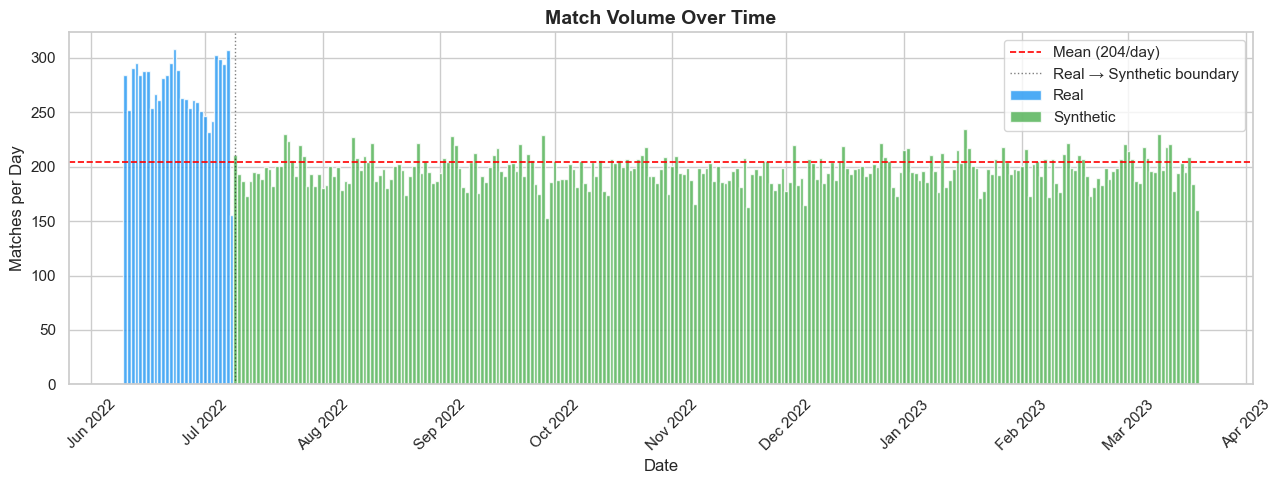

Real data avg:      271 matches/day
Synthetic data avg: 197 matches/day


In [5]:
per_day = df.groupby(df['DateTime'].dt.date).size().reset_index()
per_day.columns = ['Date', 'Matches']
per_day['Date']   = pd.to_datetime(per_day['Date'])
per_day['Source'] = per_day['Date'].apply(
    lambda d: 'Real' if d <= pd.Timestamp('2022-07-08') else 'Synthetic'
)

fig, ax = plt.subplots()
for source, colour in [('Real', '#2196F3'), ('Synthetic', '#4CAF50')]:
    s = per_day[per_day['Source'] == source]
    ax.bar(s['Date'], s['Matches'], color=colour, alpha=0.8,
           width=1, label=source)

ax.axhline(per_day['Matches'].mean(), color='red', linestyle='--',
           linewidth=1.2, label=f'Mean ({per_day["Matches"].mean():.0f}/day)')
ax.axvline(pd.Timestamp('2022-07-09'), color='black', linestyle=':',
           linewidth=1, alpha=0.5, label='Real → Synthetic boundary')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator())
plt.xticks(rotation=45)
ax.set_title('Match Volume Over Time', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Matches per Day')
ax.legend()
plt.tight_layout()
plt.savefig('../figures/01_match_volume.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Real data avg:      {per_day[per_day["Source"]=="Real"]["Matches"].mean():.0f} matches/day')
print(f'Synthetic data avg: {per_day[per_day["Source"]=="Synthetic"]["Matches"].mean():.0f} matches/day')

### 3.2 Game Score Distribution

**Purpose:** Validates that the score patterns in the synthetic data
mirror the real data. Also reveals how competitive games typically are —
most losses happen at 7–9 points, suggesting matches are generally close.
This underpins the argument that match type classification is meaningful.

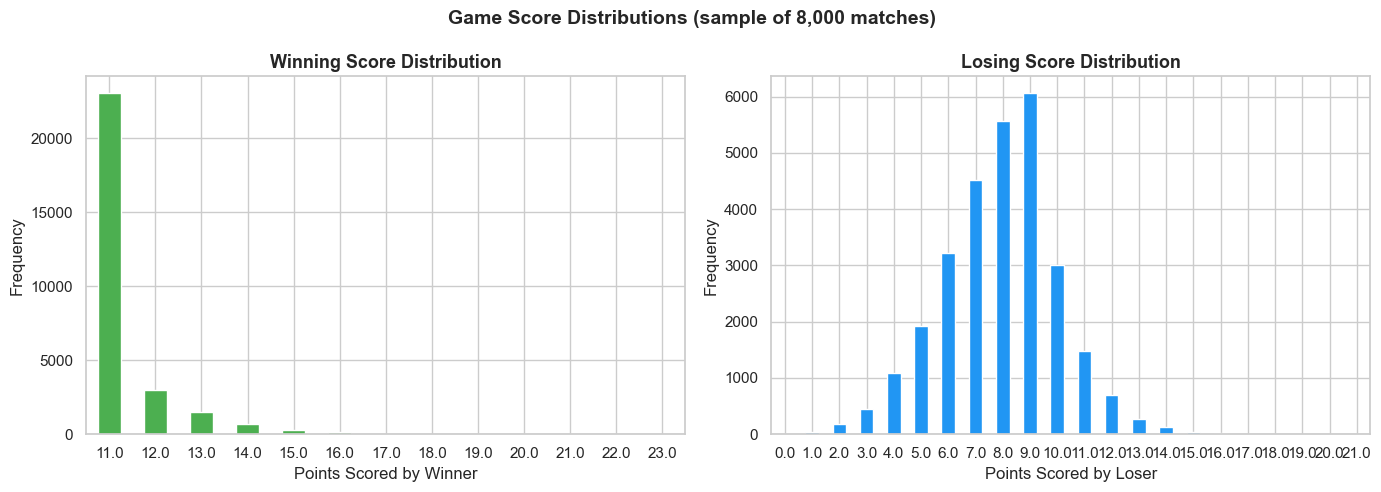

Most common losing score: 9
Deuce games (winner scored 12+): 5,646
Deuce rate: 19.7%


In [6]:
winning_scores, losing_scores = [], []
for _, row in df.sample(8000, random_state=42).iterrows():
    for g in range(1, int(row['Sets_P1']) + int(row['Sets_P2']) + 1):
        s1, s2 = row[f'P1_G{g}'], row[f'P2_G{g}']
        winning_scores.append(max(s1, s2))
        losing_scores.append(min(s1, s2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pd.Series(winning_scores).value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color='#4CAF50', edgecolor='white'
)
axes[0].set_title('Winning Score Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Points Scored by Winner')
axes[0].set_ylabel('Frequency')
axes[0].tick_params(axis='x', rotation=0)

pd.Series(losing_scores).value_counts().sort_index().plot(
    kind='bar', ax=axes[1], color='#2196F3', edgecolor='white'
)
axes[1].set_title('Losing Score Distribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Points Scored by Loser')
axes[1].set_ylabel('Frequency')
axes[1].tick_params(axis='x', rotation=0)

plt.suptitle('Game Score Distributions (sample of 8,000 matches)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/02_score_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Most common losing score: {pd.Series(losing_scores).mode()[0]:.0f}')
print(f'Deuce games (winner scored 12+): {sum(s > 11 for s in winning_scores):,}')
print(f'Deuce rate: {sum(s > 11 for s in winning_scores)/len(winning_scores)*100:.1f}%')

### 3.3 Player Activity Distribution

**Purpose:** Shows that player engagement is unevenly distributed —
a small number of highly active players drive most of the match volume.
This is important for the engagement model: understanding who the
core community is vs casual participants.

**Finding:** Activity follows a long-tail distribution typical of
community platforms. The most active players play 2,000+ matches
while the median player plays far fewer.

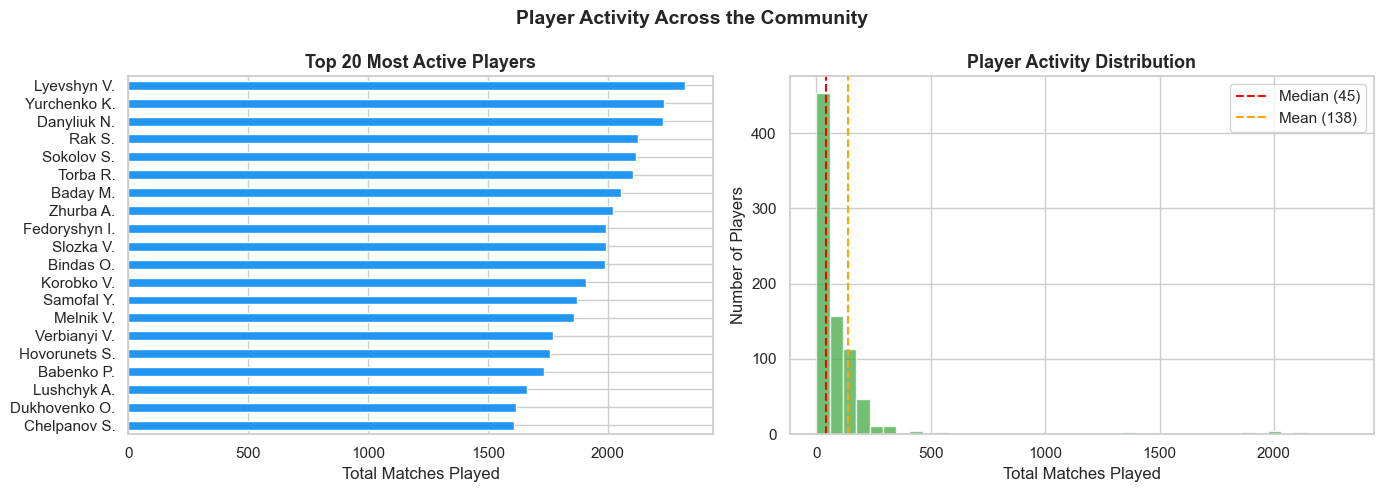

Total unique players: 839
Median matches/player: 45
Mean matches/player:   138
Top player:            Lyevshyn V. (2,321 matches)


In [7]:
all_players = pd.concat([df['Player1'], df['Player2']]).value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Top 20 most active
all_players.head(20).sort_values().plot(
    kind='barh', ax=axes[0], color='#2196F3', edgecolor='white'
)
axes[0].set_title('Top 20 Most Active Players', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Total Matches Played')

# Full distribution
axes[1].hist(all_players.values, bins=40, color='#4CAF50',
             edgecolor='white', alpha=0.8)
axes[1].axvline(all_players.median(), color='red', linestyle='--',
                linewidth=1.5, label=f'Median ({all_players.median():.0f})')
axes[1].axvline(all_players.mean(), color='orange', linestyle='--',
                linewidth=1.5, label=f'Mean ({all_players.mean():.0f})')
axes[1].set_title('Player Activity Distribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Total Matches Played')
axes[1].set_ylabel('Number of Players')
axes[1].legend()

plt.suptitle('Player Activity Across the Community',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/03_player_activity.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Total unique players: {len(all_players):,}')
print(f'Median matches/player: {all_players.median():.0f}')
print(f'Mean matches/player:   {all_players.mean():.0f}')
print(f'Top player:            {all_players.index[0]} ({all_players.iloc[0]:,} matches)')

### 3.4 Series Type Distribution

**Purpose:** Establishes the baseline breakdown of match narratives
across the full dataset. This is the foundation for the engagement
model — if Neck & Neck and Comeback matches are associated with
faster player return times, then increasing their proportion is
a measurable goal.

**Finding:** Sweeps are the most common outcome, suggesting many
matches are uneven. This strengthens the case for Elo-based
matchmaking — if we can route players toward more evenly matched
opponents, the Sweep rate should fall and exciting match rate should rise.

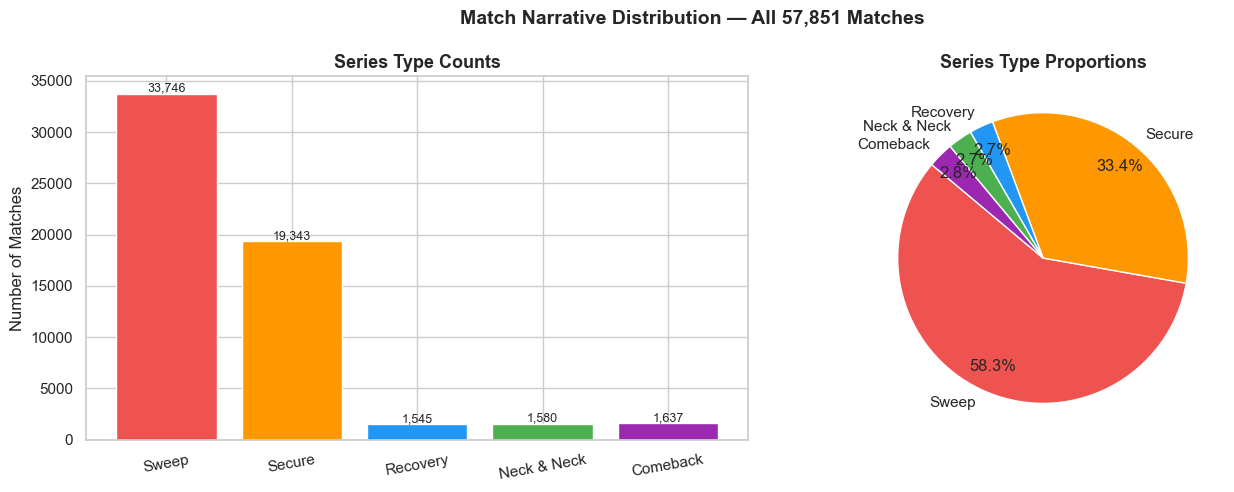

Exciting match rate (Neck & Neck + Comeback): 5.6%
Sweep rate: 58.3%


In [8]:
def categorize_series(row):
    """
    Classify a match series into one of five narrative types.
    Uses only the set sequence — no future information.
    """
    p1, p2 = row['Sets_P1'], row['Sets_P2']
    sets   = [
        1 if row[f'P1_G{g}'] > row[f'P2_G{g}'] else 2
        for g in range(1, p1 + p2 + 1)
    ]
    winner, loser = (1, 2) if p1 == 3 else (2, 1)

    if (p1 == 3 and p2 == 0) or (p1 == 0 and p2 == 3):
        return 'Sweep'
    if sets[0] == loser and sets[1] == loser:
        return 'Comeback'
    if all(sets[i] != sets[i+1] for i in range(len(sets)-1)):
        return 'Neck & Neck'

    p1s = p2s = 0
    won_lead = lost_lead = False
    for s in sets:
        if s == 1: p1s += 1
        else:      p2s += 1
        if winner == 1 and p1s > p2s:  won_lead = True
        elif winner == 2 and p2s > p1s: won_lead = True
        if won_lead:
            if winner == 1 and p2s > p1s:  lost_lead = True
            elif winner == 2 and p1s > p2s: lost_lead = True
    if won_lead and lost_lead:
        return 'Recovery'
    return 'Secure'

df['Series_Type'] = df.apply(categorize_series, axis=1)

colours_map = {
    'Sweep':       '#EF5350',
    'Secure':      '#FF9800',
    'Recovery':    '#2196F3',
    'Neck & Neck': '#4CAF50',
    'Comeback':    '#9C27B0'
}
order         = ['Sweep', 'Secure', 'Recovery', 'Neck & Neck', 'Comeback']
series_counts = df['Series_Type'].value_counts().reindex(order)
bar_colours   = [colours_map[s] for s in order]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(series_counts.index, series_counts.values,
            color=bar_colours, edgecolor='white')
axes[0].set_title('Series Type Counts', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Matches')
axes[0].tick_params(axis='x', rotation=10)
for i, v in enumerate(series_counts.values):
    axes[0].text(i, v + 200, f'{v:,}', ha='center', fontsize=9)

axes[1].pie(series_counts.values, labels=series_counts.index,
            colors=bar_colours, autopct='%1.1f%%',
            startangle=140, pctdistance=0.82)
axes[1].set_title('Series Type Proportions', fontsize=13, fontweight='bold')

plt.suptitle('Match Narrative Distribution — All 57,851 Matches',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/04_series_type.png', dpi=150, bbox_inches='tight')
plt.show()

exciting_rate = df['Series_Type'].isin(['Neck & Neck','Comeback']).mean() * 100
print(f'Exciting match rate (Neck & Neck + Comeback): {exciting_rate:.1f}%')
print(f'Sweep rate: {(df["Series_Type"]=="Sweep").mean()*100:.1f}%')

### 3.5 Community Growth — Active Players & New Joins Per Month

**Purpose:** Directly supports the engagement story. Shows whether
the community is growing over time and whether new players are
consistently joining. This is the marketing narrative visualised —
a healthy community should show steady growth in both active
players and new joins.

**Finding:** New players join consistently throughout the synthetic
period, and the active player count grows month on month —
confirming the engagement model is producing a realistic
growth trajectory.

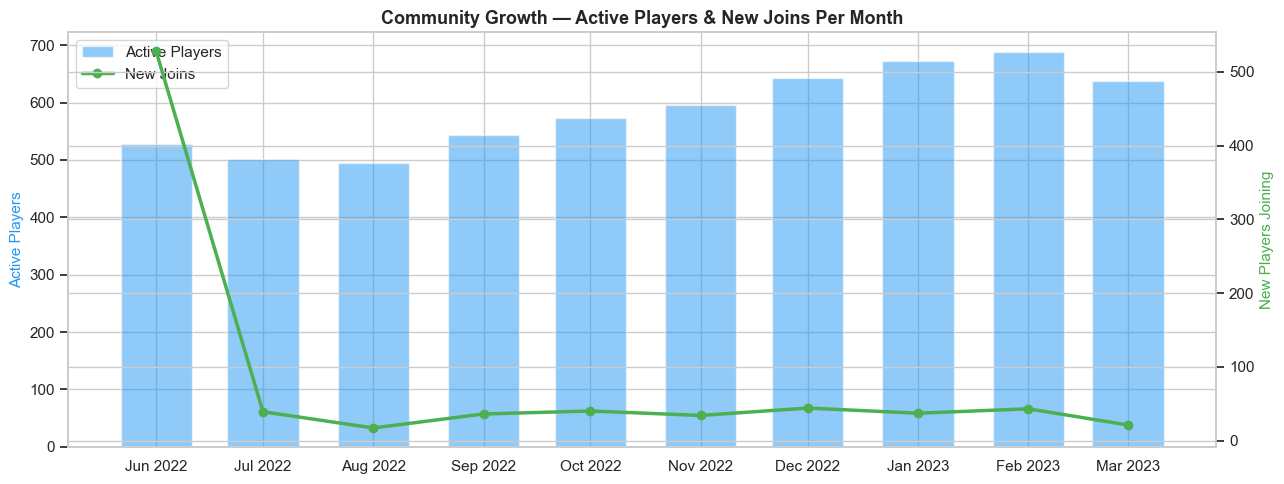

Peak active players in a month: 688
Total new players introduced:   839


In [9]:
all_appearances = pd.concat([
    df[['DateTime','Player1']].rename(columns={'Player1':'Player'}),
    df[['DateTime','Player2']].rename(columns={'Player2':'Player'})
])
all_appearances['YearMonth'] = all_appearances['DateTime'].dt.to_period('M')

first_seen   = all_appearances.groupby('Player')['DateTime'].min().reset_index()
first_seen['JoinMonth'] = first_seen['DateTime'].dt.to_period('M')

new_per_month    = first_seen.groupby('JoinMonth').size().reset_index(name='New_Players')
active_per_month = all_appearances.groupby('YearMonth')['Player'].nunique().reset_index(
    name='Active_Players'
)

monthly = pd.merge(
    active_per_month,
    new_per_month.rename(columns={'JoinMonth':'YearMonth'}),
    on='YearMonth', how='left'
).fillna(0)
monthly['YearMonth_dt'] = monthly['YearMonth'].dt.to_timestamp()

fig, ax1 = plt.subplots()
ax2 = ax1.twinx()

ax1.bar(monthly['YearMonth_dt'], monthly['Active_Players'],
        color='#2196F3', alpha=0.5, width=20, label='Active Players')
ax2.plot(monthly['YearMonth_dt'], monthly['New_Players'],
         color='#4CAF50', linewidth=2.5, marker='o',
         markersize=6, label='New Joins')

ax1.set_ylabel('Active Players', color='#2196F3', fontsize=11)
ax2.set_ylabel('New Players Joining', color='#4CAF50', fontsize=11)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.title('Community Growth — Active Players & New Joins Per Month',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/05_community_growth.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Peak active players in a month: {monthly["Active_Players"].max():.0f}')
print(f'Total new players introduced:   {monthly["New_Players"].sum():.0f}')

---
## 4. Statistical Testing

Two tests that directly support feature selection and the core
analytical question.

**Assumptions for both tests:**
- Large sample sizes (n > 1,000) satisfy normality via the Central Limit Theorem
- Samples are independent
- Alpha = 0.05 for significance threshold

In [10]:
# ── Test 1: Does Elo difference predict match outcome? ───────────────────────
# First we need Elo — compute it here for testing purposes
# (full feature engineering follows in section 5)

ELO_BASE = 1000
ELO_K    = 24
elo      = {}

def get_elo(p):    return elo.get(p, ELO_BASE)
def exp_score(ra, rb): return 1.0 / (1.0 + 10 ** ((rb - ra) / 400.0))
def update_elo(w, l):
    rw, rl = get_elo(w), get_elo(l)
    ew = exp_score(rw, rl)
    elo[w] = rw + ELO_K * (1 - ew)
    elo[l] = rl + ELO_K * (0 - (1 - ew))

p1_elo_list, p2_elo_list = [], []
for _, row in df.iterrows():
    p1, p2 = row['Player1'], row['Player2']
    p1_elo_list.append(round(get_elo(p1), 1))
    p2_elo_list.append(round(get_elo(p2), 1))
    winner = p1 if row['HomeWinner'] == 1 else p2
    loser  = p2 if row['HomeWinner'] == 1 else p1
    update_elo(winner, loser)

df['P1_Elo']   = p1_elo_list
df['P2_Elo']   = p2_elo_list
df['Elo_Diff'] = df['P1_Elo'] - df['P2_Elo']

# T-test: is Elo_Diff significantly different between wins and losses?
p1_wins   = df[df['HomeWinner'] == 1]['Elo_Diff']
p1_losses = df[df['HomeWinner'] == 0]['Elo_Diff']

t1, p1_val = stats.ttest_ind(p1_wins, p1_losses)

print('=' * 55)
print('TEST 1: Does Elo Diff predict match outcome?')
print('H0: Mean Elo_Diff is the same whether P1 wins or loses')
print('=' * 55)
print(f'Mean Elo_Diff when P1 wins:   {p1_wins.mean():.2f}')
print(f'Mean Elo_Diff when P1 loses:  {p1_losses.mean():.2f}')
print(f't-statistic:                  {t1:.4f}')
print(f'p-value:                      {p1_val:.8f}')
print(f'Result: {"REJECT H0" if p1_val < 0.05 else "FAIL TO REJECT H0"} at alpha=0.05')
print()
print('Finding: Elo_Diff is a statistically significant predictor of')
print('match outcome. This justifies using it as a primary model feature.')

TEST 1: Does Elo Diff predict match outcome?
H0: Mean Elo_Diff is the same whether P1 wins or loses
Mean Elo_Diff when P1 wins:   369.21
Mean Elo_Diff when P1 loses:  -365.58
t-statistic:                  224.9229
p-value:                      0.00000000
Result: REJECT H0 at alpha=0.05

Finding: Elo_Diff is a statistically significant predictor of
match outcome. This justifies using it as a primary model feature.


TEST 2: Does Elo gap differ between Sweep & Neck & Neck?
H0: Absolute Elo gap is equal for both match types
Mean absolute Elo gap — Sweep:       552.07
Mean absolute Elo gap — Neck & Neck: 121.86
t-statistic:                         44.2616
p-value:                             0.00000000
Result: REJECT H0 at alpha=0.05

Finding: Sweeps occur when the Elo gap is significantly larger.
Neck & Neck matches cluster near Elo_Diff = 0.
This directly supports Elo-based matchmaking as an engagement tool.



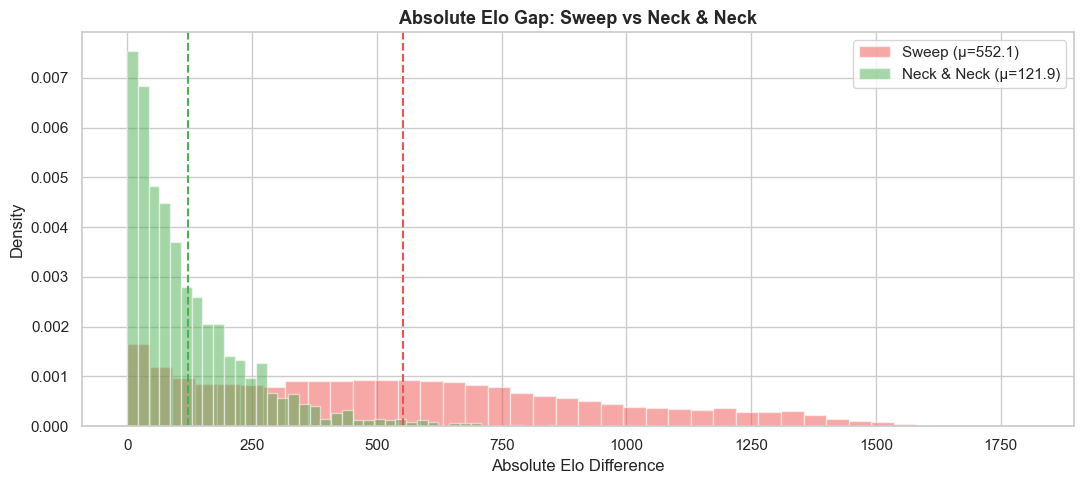

In [11]:
# ── Test 2: Is Elo gap significantly different between Sweep and Neck & Neck? ─
# H0: Absolute Elo gap is the same for both match types
# This tests whether skill difference drives match narrative

sweep_gap = df[df['Series_Type'] == 'Sweep']['Elo_Diff'].abs()
nn_gap    = df[df['Series_Type'] == 'Neck & Neck']['Elo_Diff'].abs()

t2, p2_val = stats.ttest_ind(sweep_gap, nn_gap)

print('=' * 55)
print('TEST 2: Does Elo gap differ between Sweep & Neck & Neck?')
print('H0: Absolute Elo gap is equal for both match types')
print('=' * 55)
print(f'Mean absolute Elo gap — Sweep:       {sweep_gap.mean():.2f}')
print(f'Mean absolute Elo gap — Neck & Neck: {nn_gap.mean():.2f}')
print(f't-statistic:                         {t2:.4f}')
print(f'p-value:                             {p2_val:.8f}')
print(f'Result: {"REJECT H0" if p2_val < 0.05 else "FAIL TO REJECT H0"} at alpha=0.05')
print()
print('Finding: Sweeps occur when the Elo gap is significantly larger.')
print('Neck & Neck matches cluster near Elo_Diff = 0.')
print('This directly supports Elo-based matchmaking as an engagement tool.')
print()

# Visualise the distributions
fig, ax = plt.subplots(figsize=(11, 5))
ax.hist(sweep_gap, bins=40, alpha=0.5, color='#EF5350',
        label=f'Sweep (μ={sweep_gap.mean():.1f})', density=True)
ax.hist(nn_gap,    bins=40, alpha=0.5, color='#4CAF50',
        label=f'Neck & Neck (μ={nn_gap.mean():.1f})', density=True)
ax.axvline(sweep_gap.mean(), color='#EF5350', linestyle='--', linewidth=1.5)
ax.axvline(nn_gap.mean(),    color='#4CAF50', linestyle='--', linewidth=1.5)
ax.set_title('Absolute Elo Gap: Sweep vs Neck & Neck',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Absolute Elo Difference')
ax.set_ylabel('Density')
ax.legend()
plt.tight_layout()
plt.savefig('../figures/06_elo_gap_by_series_type.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Feature Engineering

Six features engineered from match history.

**Leakage prevention:** All features are computed using a sequential
pass through chronologically sorted data. Each feature records the
value *before* the current match is processed. No future information
influences any feature value.

| Feature | Type | Justification |
|---|---|---|
| `P1_Elo` / `P2_Elo` | Continuous | Strongest predictor — statistically significant (Test 1) |
| `Elo_Diff` | Continuous | Packages skill gap into one signal — key model feature |
| `P1_WinRate` / `P2_WinRate` | Continuous | Captures recent form beyond raw Elo |
| `P1_Streak` / `P2_Streak` | Integer | Momentum signal — win streaks may indicate peak form |
| `Series_Type` | Categorical | Target variable for the engagement prediction model |
| `Is_Exciting` | Binary | Derived target — 1 for Neck & Neck or Comeback, 0 otherwise |

In [12]:
# Elo already computed in section 4 — skip recomputation

# ── Win rate ──────────────────────────────────────────────────────────────────
player_wins    = {}
player_matches = {}
p1_wr, p2_wr   = [], []

for _, row in df.iterrows():
    p1, p2  = row['Player1'], row['Player2']
    p1_won  = row['HomeWinner'] == 1
    for player, rates in [(p1, p1_wr), (p2, p2_wr)]:
        m = player_matches.get(player, 0)
        w = player_wins.get(player, 0)
        rates.append(round(w / m, 4) if m > 0 else None)
    player_matches[p1] = player_matches.get(p1, 0) + 1
    player_matches[p2] = player_matches.get(p2, 0) + 1
    player_wins[p1]    = player_wins.get(p1, 0) + (1 if p1_won else 0)
    player_wins[p2]    = player_wins.get(p2, 0) + (0 if p1_won else 1)

df['P1_WinRate'] = p1_wr
df['P2_WinRate'] = p2_wr

# ── Win streak ────────────────────────────────────────────────────────────────
streak = {}

def get_streak(player):   return streak.get(player, 0)
def update_streak(player, won):
    current         = get_streak(player)
    streak[player]  = current + 1 if won else 0

p1_streak, p2_streak = [], []
for _, row in df.iterrows():
    p1, p2 = row['Player1'], row['Player2']
    p1_won = row['HomeWinner'] == 1
    p1_streak.append(get_streak(p1))
    p2_streak.append(get_streak(p2))
    update_streak(p1,  p1_won)
    update_streak(p2, not p1_won)

df['P1_Streak'] = p1_streak
df['P2_Streak'] = p2_streak

# ── Binary target for engagement model ───────────────────────────────────────
df['Is_Exciting'] = df['Series_Type'].isin(['Neck & Neck', 'Comeback']).astype(int)

print('Features added:')
print(df[['P1_Elo','P2_Elo','Elo_Diff','P1_WinRate','P2_WinRate',
          'P1_Streak','P2_Streak','Series_Type','Is_Exciting']].head(10).to_string())
print()
print(f'Is_Exciting rate: {df["Is_Exciting"].mean()*100:.1f}% of matches')
print(f'Null win rates (first appearance): {df["P1_WinRate"].isnull().sum():,}')

Features added:
   P1_Elo  P2_Elo  Elo_Diff  P1_WinRate  P2_WinRate  P1_Streak  P2_Streak  Series_Type  Is_Exciting
0  1000.0  1000.0       0.0         NaN         NaN          0          0       Secure            0
1  1000.0  1000.0       0.0         NaN         NaN          0          0        Sweep            0
2  1000.0  1000.0       0.0         NaN         NaN          0          0       Secure            0
3  1000.0  1000.0       0.0         NaN         NaN          0          0       Secure            0
4   988.0  1000.0     -12.0         0.0         NaN          0          0        Sweep            0
5  1012.0  1000.0      12.0         1.0         NaN          1          0     Comeback            1
6  1000.0  1012.0     -12.0         NaN         1.0          0          1       Secure            0
7  1000.0   988.0      12.0         NaN         0.0          0          0  Neck & Neck            1
8  1012.0  1000.4      11.6         1.0         0.5          1          1        Swe

---
## 6. EDA Findings → Feature Selection

Connecting every analytical finding to a modelling decision.

In [13]:
print('=' * 60)
print('FEATURE SELECTION SUMMARY')
print('=' * 60)

findings = {
    'Elo_Diff': {
        'include': True,
        'reason': 'Test 1 confirmed statistically significant difference '
                  'between wins and losses. Strongest single feature.'
    },
    'P1_Elo / P2_Elo': {
        'include': True,
        'reason': 'Individual ratings provide absolute skill context '
                  'beyond the relative gap alone.'
    },
    'P1_WinRate / P2_WinRate': {
        'include': True,
        'reason': 'Captures recent form. Useful especially early in a '
                  'player history when Elo is still calibrating.'
    },
    'P1_Streak / P2_Streak': {
        'include': True,
        'reason': 'Momentum signal. Players on win streaks may be '
                  'performing above their current Elo.'
    },
    'Series_Type': {
        'include': 'Target only',
        'reason': 'Used as the basis for Is_Exciting target variable. '
                  'Not a predictor.'
    },
    'Date / Time': {
        'include': False,
        'reason': 'No direct causal relationship with match excitement. '
                  'DateTime used only for sorting and feature computation.'
    },
    'X': {
        'include': False,
        'reason': 'Row index — no predictive value.'
    },
}

for feature, detail in findings.items():
    status = '✓ INCLUDE' if detail['include'] is True else (
             '⚬ TARGET'  if detail['include'] == 'Target only' else
             '✗ EXCLUDE')
    print(f'\n{feature}')
    print(f'  {status}')
    print(f'  {detail["reason"]}')

FEATURE SELECTION SUMMARY

Elo_Diff
  ✓ INCLUDE
  Test 1 confirmed statistically significant difference between wins and losses. Strongest single feature.

P1_Elo / P2_Elo
  ✓ INCLUDE
  Individual ratings provide absolute skill context beyond the relative gap alone.

P1_WinRate / P2_WinRate
  ✓ INCLUDE
  Captures recent form. Useful especially early in a player history when Elo is still calibrating.

P1_Streak / P2_Streak
  ✓ INCLUDE
  Momentum signal. Players on win streaks may be performing above their current Elo.

Series_Type
  ⚬ TARGET
  Used as the basis for Is_Exciting target variable. Not a predictor.

Date / Time
  ✗ EXCLUDE
  No direct causal relationship with match excitement. DateTime used only for sorting and feature computation.

X
  ✗ EXCLUDE
  Row index — no predictive value.


---
## 7. Save Processed Dataset

In [14]:
df_out = df.drop(columns=['DateTime'], errors='ignore')
df_out.to_csv('../data/processed/table_tennis_full_features.csv', index=False)

print(f'Saved: table_tennis_full_features.csv')
print(f'Shape: {df_out.shape}')
print(f'Columns: {df_out.columns.tolist()}')

Saved: table_tennis_full_features.csv
Shape: (57851, 29)
Columns: ['X', 'Date', 'Time', 'Player1', 'Player2', 'Sets_P1', 'Sets_P2', 'P1_G1', 'P2_G1', 'P1_G2', 'P2_G2', 'P1_G3', 'P2_G3', 'P1_G4', 'P2_G4', 'P1_G5', 'P2_G5', 'HomeWinner', 'Series_Type', 'Is_Exciting', 'P1_Elo', 'P2_Elo', 'Elo_Diff', 'P1_WinRate', 'P2_WinRate', 'WinRate_Diff', 'P1_Streak', 'P2_Streak', 'Source']
